# DATA 221 Project — Image Preprocessing for Fruit Classification

## Objective
In this notebook, I prepare the fruit image dataset for model training. To ensure a fair comparison across models, I use the same official Fruits-360 split for all models. The official **Train** folder is further divided into training and validation sets using an **85/15 split**, while the official **Test** folder is reserved only for final evaluation.

The preprocessing steps include:
- listing the raw dataset folders,
- combining selected raw folders into four final project classes,
- balancing image counts across classes,
- creating shared project folders for the whole group.

This notebook creates one consistent dataset pipeline to create training, testing, validation that can later be reused by members in the group for a consistent train test split.

## Dataset Description

https://www.kaggle.com/datasets/moltean/fruits

For this project, our group uses a subset of the **Fruits-360** dataset, available in the link provided above. The original dataset contains many raw folders, including multiple subclasses for some fruits. For example, apples may appear in folders such as **Apple Red 1** and **Apple Red 2**.

Since our project compares only four final classes, I combine selected raw folders into the following final labels:

- Apple
- Avocado
- Banana
- Orange

The dataset already provides separate **Train** and **Test** folders. To avoid data leakage and ensure fair evaluation:
- the official **Train** folder will be split into:
  - **85% actual training**
  - **15% validation**
- the official **Test** folder will remain separate and will only be used later for final model evaluation.

To make the comparison fair, I balance the number of images across the four final classes using Python instead of manually deleting files.

In [ ]:
import os
import shutil
from pathlib import Path
import random
from collections import Counter, defaultdict

import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Reproducibility
random.seed(42)
np.random.seed(42)

## Step 1 — Define dataset paths, final class names, and class mapping

In this step, I define:
- the dataset root folder,
- the official training folder,
- the official testing folder,
- the new shared project folders,
- the four final project classes,
- the mapping from raw Fruits-360 folders into final class labels,
- and the image size for preprocessing.

This mapping allows multiple raw folders to be merged into one final class, which is especially useful for Apple.

In [3]:
DATASET_ROOT = Path("fruits-360")
TRAIN_DIR = DATASET_ROOT / "Training"
TEST_DIR  = DATASET_ROOT / "Test"

PROJECT_TRAIN_DIR = DATASET_ROOT / "Project_Train"
PROJECT_VAL_DIR   = DATASET_ROOT / "Project_Val"
PROJECT_TEST_DIR  = DATASET_ROOT / "Project_Test"

IMG_SIZE = (100, 100)

OUTPUT_DIR = Path("processed_data")
OUTPUT_DIR.mkdir(exist_ok=True)

FINAL_CLASSES = ["Apple", "Banana", "Avocado", "Orange"]

CLASS_MAPPING = {
    "Apple":   ["Apple Red 1", "Apple Red 2", "Apple Red 3"],
    "Avocado": ["Avocado 1", "Avocado Black 1", "Avocado 2"],
    "Banana":  ["Banana 1", "Banana 3", "Banana 4"],
    "Orange":  ["Orange 1", "Orange 2", "Orange 3"]
}

print("Dataset root      :", DATASET_ROOT)
print("Official train    :", TRAIN_DIR)
print("Official test     :", TEST_DIR)
print("Project train dir :", PROJECT_TRAIN_DIR)
print("Project val dir   :", PROJECT_VAL_DIR)
print("Project test dir  :", PROJECT_TEST_DIR)

Dataset root      : fruits-360
Official train    : fruits-360/Training
Official test     : fruits-360/Test
Project train dir : fruits-360/Project_Train
Project val dir   : fruits-360/Project_Val
Project test dir  : fruits-360/Project_Test


## Step 2 — List all available raw folders

Before selecting the final classes, I inspect the available raw folders in the official training and testing directories. This helps confirm the exact folder names used by Fruits-360, which is important because the class mapping must match those names exactly.

In [4]:
train_raw_folders = sorted([p.name for p in TRAIN_DIR.iterdir() if p.is_dir()])
test_raw_folders = sorted([p.name for p in TEST_DIR.iterdir() if p.is_dir()])

print("Number of raw folders in official TRAIN:", len(train_raw_folders))
print("Number of raw folders in official TEST :", len(test_raw_folders))

print("\nFirst 40 raw TRAIN folders:")
for name in train_raw_folders[:40]:
    print("-", name)

print("\nFirst 40 raw TEST folders:")
for name in test_raw_folders[:40]:
    print("-", name)

Number of raw folders in official TRAIN: 253
Number of raw folders in official TEST : 253

First 40 raw TRAIN folders:
- Almonds 1
- Apple 10
- Apple 11
- Apple 12
- Apple 13
- Apple 14
- Apple 17
- Apple 18
- Apple 19
- Apple 20
- Apple 21
- Apple 22
- Apple 23
- Apple 5
- Apple 6
- Apple 7
- Apple 8
- Apple 9
- Apple Braeburn 1
- Apple Crimson Snow 1
- Apple Golden 1
- Apple Golden 2
- Apple Golden 3
- Apple Granny Smith 1
- Apple Pink Lady 1
- Apple Red 1
- Apple Red 2
- Apple Red 3
- Apple Red Delicious 1
- Apple Red Yellow 1
- Apple Red Yellow 2
- Apricot 1
- Avocado 1
- Avocado 2
- Avocado Black 1
- Avocado Black 2
- Avocado Green 1
- Banana 1
- Banana 3
- Banana 4

First 40 raw TEST folders:
- Almonds 1
- Apple 10
- Apple 11
- Apple 12
- Apple 13
- Apple 14
- Apple 17
- Apple 18
- Apple 19
- Apple 20
- Apple 21
- Apple 22
- Apple 23
- Apple 5
- Apple 6
- Apple 7
- Apple 8
- Apple 9
- Apple Braeburn 1
- Apple Crimson Snow 1
- Apple Golden 1
- Apple Golden 2
- Apple Golden 3
- App

## Step 3 — Check that the selected raw folders exist

Here I verify that every raw folder listed in the class mapping exists in both the official training and testing directories. This is an important validation step before combining folders into the four final project classes.

In [5]:
for final_label, raw_folders in CLASS_MAPPING.items():
    print(f"\nFinal class: {final_label}")
    for raw_name in raw_folders:
        train_exists = (TRAIN_DIR / raw_name).exists()
        test_exists = (TEST_DIR / raw_name).exists()
        print(f"  Raw folder: {raw_name}")
        print(f"    Train exists: {train_exists}")
        print(f"    Test exists : {test_exists}")


Final class: Apple
  Raw folder: Apple Red 1
    Train exists: True
    Test exists : True
  Raw folder: Apple Red 2
    Train exists: True
    Test exists : True
  Raw folder: Apple Red 3
    Train exists: True
    Test exists : True

Final class: Avocado
  Raw folder: Avocado 1
    Train exists: True
    Test exists : True
  Raw folder: Avocado Black 1
    Train exists: True
    Test exists : True
  Raw folder: Avocado 2
    Train exists: True
    Test exists : True

Final class: Banana
  Raw folder: Banana 1
    Train exists: True
    Test exists : True
  Raw folder: Banana 3
    Train exists: True
    Test exists : True
  Raw folder: Banana 4
    Train exists: True
    Test exists : True

Final class: Orange
  Raw folder: Orange 1
    Train exists: True
    Test exists : True
  Raw folder: Orange 2
    Train exists: True
    Test exists : True
  Raw folder: Orange 3
    Train exists: True
    Test exists : True


## Step 4 — Count images in each selected raw folder

Now I count the number of images available in each selected raw folder. This helps me understand how many images contribute to each final class and helps determine the balancing step later.

In [6]:
VALID_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp"}

def count_images_in_folder(folder_path):
    return len([f for f in folder_path.iterdir() if f.suffix.lower() in VALID_EXTENSIONS])

train_raw_counts = {}
test_raw_counts = {}

for final_label, raw_folders in CLASS_MAPPING.items():
    for raw_name in raw_folders:
        train_raw_counts[raw_name] = count_images_in_folder(TRAIN_DIR / raw_name)
        test_raw_counts[raw_name] = count_images_in_folder(TEST_DIR / raw_name)

print("Selected raw-folder counts in official TRAIN:")
for raw_name, count in train_raw_counts.items():
    print(f"{raw_name}: {count}")

print("\nSelected raw-folder counts in official TEST:")
for raw_name, count in test_raw_counts.items():
    print(f"{raw_name}: {count}")

Selected raw-folder counts in official TRAIN:
Apple Red 1: 492
Apple Red 2: 492
Apple Red 3: 429
Avocado 1: 427
Avocado Black 1: 702
Avocado 2: 491
Banana 1: 490
Banana 3: 233
Banana 4: 254
Orange 1: 479
Orange 2: 702
Orange 3: 716

Selected raw-folder counts in official TEST:
Apple Red 1: 164
Apple Red 2: 164
Apple Red 3: 144
Avocado 1: 143
Avocado Black 1: 231
Avocado 2: 166
Banana 1: 166
Banana 3: 77
Banana 4: 84
Orange 1: 160
Orange 2: 231
Orange 3: 237


## Step 5 — Define helper functions for combining, balancing, and copying images

In this step, I define helper functions that will:
- collect images from the raw folders,
- combine them into the four final classes,
- balance image counts across classes,
- reset the shared project folders,
- and copy selected images into those shared folders.

This allows the whole group to use one consistent train, validation, and test split without changing the original Fruits-360 dataset.

In [7]:
def gather_image_paths_from_mapping(base_dir, class_mapping):
    """
    Collect image paths and assign final labels based on CLASS_MAPPING.
    """
    image_paths = []
    labels = []

    for final_label, raw_folders in class_mapping.items():
        for raw_name in raw_folders:
            raw_folder = base_dir / raw_name
            for file_path in raw_folder.iterdir():
                if file_path.suffix.lower() in VALID_EXTENSIONS:
                    image_paths.append(file_path)
                    labels.append(final_label)

    return image_paths, labels


def balance_dataset(image_paths, labels, random_state=42):
    """
    Balance the dataset by downsampling each final class
    to the size of the smallest class.
    """
    grouped = defaultdict(list)
    for path, label in zip(image_paths, labels):
        grouped[label].append(path)

    counts = {label: len(paths) for label, paths in grouped.items()}
    min_count = min(counts.values())

    rng = random.Random(random_state)

    balanced_paths = []
    balanced_labels = []

    for label in sorted(grouped.keys()):
        sampled_paths = grouped[label].copy()
        rng.shuffle(sampled_paths)
        sampled_paths = sampled_paths[:min_count]

        balanced_paths.extend(sampled_paths)
        balanced_labels.extend([label] * min_count)

    combined = list(zip(balanced_paths, balanced_labels))
    rng.shuffle(combined)

    balanced_paths, balanced_labels = zip(*combined)
    return list(balanced_paths), list(balanced_labels), counts, min_count


def reset_project_folder(folder_path, class_names):
    """
    Delete an existing project folder if it exists,
    then recreate it with one subfolder per final class.
    """
    if folder_path.exists():
        shutil.rmtree(folder_path)

    folder_path.mkdir(parents=True, exist_ok=True)

    for class_name in class_names:
        (folder_path / class_name).mkdir(parents=True, exist_ok=True)


def copy_images_to_project_folder(image_paths, labels, destination_root):
    """
    Copy selected images into a destination root folder under final class folders.
    Creates clean unique filenames to avoid collisions.
    """
    class_counters = defaultdict(int)

    for src_path, label in zip(image_paths, labels):
        class_counters[label] += 1
        new_name = f"{label.lower()}_{class_counters[label]:05d}{src_path.suffix.lower()}"
        dst_path = destination_root / label / new_name
        shutil.copy2(src_path, dst_path)

## Step 6 — Combine raw folders into the four final project classes

In this step, I use the class mapping to combine selected raw Fruits-360 folders into the four final project labels:
- Apple
- Banana
- Avocado
- Orange

I do this separately for the official Train folder and the official Test folder.

In [9]:
# Collect all candidate images from official folders
trainval_paths_all, trainval_labels_all = gather_image_paths_from_mapping(TRAIN_DIR, CLASS_MAPPING)
test_paths_all, test_labels_all = gather_image_paths_from_mapping(TEST_DIR, CLASS_MAPPING)

print("Combined final-class counts from official TRAIN:")
print(Counter(trainval_labels_all))

print("\nCombined final-class counts from official TEST:")
print(Counter(test_labels_all))

Combined final-class counts from official TRAIN:
Counter({'Orange': 1897, 'Avocado': 1620, 'Apple': 1413, 'Banana': 977})

Combined final-class counts from official TEST:
Counter({'Orange': 628, 'Avocado': 540, 'Apple': 472, 'Banana': 327})


## Step 7 — Balance image counts for official Train and official Test

Because different classes may have different numbers of images, I balance the dataset by downsampling each final class to the same count.

I do this separately for:
- the official **Train** folder data
- the official **Test** folder data

This ensures that the final classes are equally represented.

In [10]:
# Balance official Train data
trainval_paths_bal, trainval_labels_bal, train_counts_before, train_min_count = balance_dataset(
    trainval_paths_all, trainval_labels_all, random_state=42
)

# Balance official Test data
test_paths_bal, test_labels_bal, test_counts_before, test_min_count = balance_dataset(
    test_paths_all, test_labels_all, random_state=42
)

print("Original combined TRAIN counts:")
print(train_counts_before)
print("Balanced TRAIN count per class:", train_min_count)

print("\nOriginal combined TEST counts:")
print(test_counts_before)
print("Balanced TEST count per class :", test_min_count)

print("\nBalanced TRAIN distribution:")
print(Counter(trainval_labels_bal))

print("\nBalanced TEST distribution:")
print(Counter(test_labels_bal))

Original combined TRAIN counts:
{'Apple': 1413, 'Avocado': 1620, 'Banana': 977, 'Orange': 1897}
Balanced TRAIN count per class: 977

Original combined TEST counts:
{'Apple': 472, 'Avocado': 540, 'Banana': 327, 'Orange': 628}
Balanced TEST count per class : 327

Balanced TRAIN distribution:
Counter({'Orange': 977, 'Banana': 977, 'Avocado': 977, 'Apple': 977})

Balanced TEST distribution:
Counter({'Orange': 327, 'Banana': 327, 'Avocado': 327, 'Apple': 327})


## Step 8 — Split the balanced official Train data into training and validation sets

After balancing the official Train data, I split it into:
- **85% actual training**
- **15% validation**

I use a stratified split so that the class proportions remain balanced in both subsets.

The balanced official Test data remains separate and is kept for final model evaluation only.

In [11]:
train_paths, val_paths, train_labels, val_labels = train_test_split(
    trainval_paths_bal,
    trainval_labels_bal,
    test_size=0.15,
    random_state=42,
    stratify=trainval_labels_bal
)

print("Balanced official TRAIN total:", len(trainval_paths_bal))
print("Actual training images       :", len(train_paths))
print("Validation images            :", len(val_paths))
print("Balanced official TEST total :", len(test_paths_bal))

print("\nTraining distribution:")
print(Counter(train_labels))

print("\nValidation distribution:")
print(Counter(val_labels))

print("\nTest distribution:")
print(Counter(test_labels_bal))

Balanced official TRAIN total: 3908
Actual training images       : 3321
Validation images            : 587
Balanced official TEST total : 1308

Training distribution:
Counter({'Avocado': 831, 'Orange': 830, 'Apple': 830, 'Banana': 830})

Validation distribution:
Counter({'Apple': 147, 'Orange': 147, 'Banana': 147, 'Avocado': 146})

Test distribution:
Counter({'Orange': 327, 'Banana': 327, 'Avocado': 327, 'Apple': 327})


## Step 9 — Create shared group folders for the consistent split

To make sure all group members use the same exact dataset split, I create new shared folders inside the Fruits-360 dataset directory. I keep the original official `Training` and `Test` folders unchanged, then use Python to copy the selected images into:

- `Project_Train`
- `Project_Val`
- `Project_Test`

This gives the whole group one consistent split while still allowing each member to apply their own model-specific preprocessing later.

In [12]:
# Reset project folders
reset_project_folder(PROJECT_TRAIN_DIR, FINAL_CLASSES)
reset_project_folder(PROJECT_VAL_DIR, FINAL_CLASSES)
reset_project_folder(PROJECT_TEST_DIR, FINAL_CLASSES)

# Copy selected images into the shared project folders
copy_images_to_project_folder(train_paths, train_labels, PROJECT_TRAIN_DIR)
copy_images_to_project_folder(val_paths, val_labels, PROJECT_VAL_DIR)
copy_images_to_project_folder(test_paths_bal, test_labels_bal, PROJECT_TEST_DIR)

print("Project folders created successfully.")
print("Shared dataset folders ready for the group:")
print(" -", PROJECT_TRAIN_DIR)
print(" -", PROJECT_VAL_DIR)
print(" -", PROJECT_TEST_DIR)

Project folders created successfully.
Shared dataset folders ready for the group:
 - fruits-360/Project_Train
 - fruits-360/Project_Val
 - fruits-360/Project_Test


## Step 10 — Display sample images from the balanced dataset

Before full preprocessing, I visualize a few sample images from the selected dataset. This helps confirm that the class mapping, balancing, and data selection worked correctly.

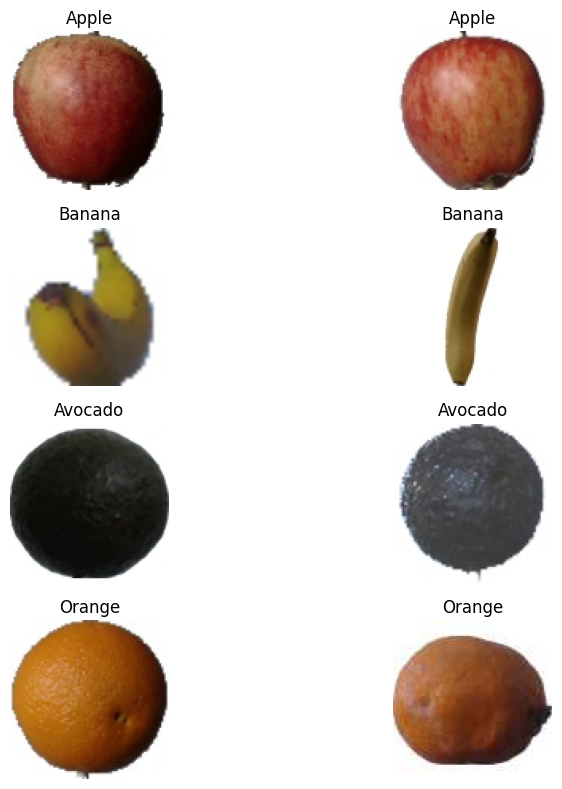

In [13]:
def show_sample_images_from_paths(paths, labels, class_names, samples_per_class=2):
    plt.figure(figsize=(10, 8))
    plot_index = 1

    for class_name in class_names:
        class_paths = [p for p, lbl in zip(paths, labels) if lbl == class_name][:samples_per_class]

        for img_path in class_paths:
            img = cv2.imread(str(img_path))
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

            plt.subplot(len(class_names), samples_per_class, plot_index)
            plt.imshow(img)
            plt.title(class_name)
            plt.axis("off")
            plot_index += 1

    plt.tight_layout()
    plt.show()

show_sample_images_from_paths(trainval_paths_bal, trainval_labels_bal, FINAL_CLASSES, samples_per_class=2)